# D2 - Analysing Patient Outcomes Across Hospitals

Module: DS Python Fundamentals  
Dataset: `Data/topic_D2_hospital_outcomes_raw.csv` (1400 patients, 3 hospitals)

## Objective
Assess differences in patient outcomes between hospitals and critically evaluate whether these comparisons are valid and meaningful.

The key challenge: hospitals treat different patient populations. A hospital treating more severe cases will naturally show worse raw outcomes, even if it delivers better care. This notebook investigates whether raw comparisons are fair, and how to adjust for confounding variables.

In [1]:
# Standard data science libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

# Make plots look clean
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Make sure the Plots folder exists before saving figures
os.makedirs("Plots", exist_ok=True)

## 1. Problem Framing

We have outcome data for 1400 patients treated across three hospitals (A, B, C). Each row represents one patient with the following information:

- Who they are: age, severity of illness, comorbidity score
- What treatment they received: standard or advanced
- What happened: did they recover, how long did they stay, were they readmitted

### The core question
Which hospital performs best, and can we trust that conclusion?

### The trap
If Hospital B treats more high-severity patients, it will show lower recovery rates simply because of the patient mix, not because of worse care. This is called confounding: a hidden variable (severity) distorts the comparison.

### Our approach
1. Start with a naive (unadjusted) comparison to see the misleading picture
2. Investigate the patient population differences
3. Re-compare within severity groups (adjusted) to get the fair picture
4. Reflect critically on limitations

## 2. Data Understanding

### Dataset overview
| Column | Type | Description |
|---|---|---|
| patient_id | string | Unique patient identifier |
| hospital | string | Hospital_A, Hospital_B, or Hospital_C |
| age | int | Patient age (18 to 95) |
| severity | string | Illness severity: low / medium / high |
| comorbidity_score | int | Number of additional conditions |
| treatment_type | string | standard or advanced treatment |
| recovered | int | 1 = recovered, 0 = did not recover |
| length_of_stay_days | float | Days spent in hospital |
| readmitted_30d | int | 1 = readmitted within 30 days |

### Key outcome variables
- `recovered`: primary outcome (binary)
- `length_of_stay_days`: efficiency indicator
- `readmitted_30d`: quality indicator

In [3]:
# Load the dataset from the Data folder
df = pd.read_csv("Data/topic_D2_hospital_outcomes_raw.csv")

# Quick sanity check
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (1400, 9)

Column types:
patient_id                 str
hospital                   str
age                      int64
severity                   str
comorbidity_score        int64
treatment_type             str
recovered                int64
length_of_stay_days    float64
readmitted_30d           int64
dtype: object

First 5 rows:


,patient_id,hospital,age,severity,comorbidity_score,treatment_type,recovered,length_of_stay_days,readmitted_30d
0,P200000,Hospital_C,78,low,3,standard,1,3.8,0
1,P200001,Hospital_A,69,low,3,standard,1,5.1,0
2,P200002,Hospital_A,70,low,2,standard,1,2.6,0
3,P200003,Hospital_A,87,low,0,standard,1,4.1,0
4,P200004,Hospital_B,32,medium,5,standard,0,7.9,0


In [4]:
# Summary statistics for numeric columns
df.describe().round(2)

,age,comorbidity_score,recovered,length_of_stay_days,readmitted_30d
count,1400.00,1400.00,1400.00,1400.0,1400.00
mean,59.24,2.47,0.74,6.2,0.09
std,17.85,1.93,0.44,3.7,0.29
min,18.00,0.00,0.00,1.0,0.00
25%,47.00,1.00,0.00,3.4,0.00
50%,59.00,2.00,1.00,5.1,0.00
75%,72.00,4.00,1.00,8.2,0.00
max,95.00,11.00,1.00,22.4,1.00


In [5]:
# Check if any data is missing
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nNo missing values:", missing.sum() == 0)

Missing values per column:
patient_id             0
hospital               0
age                    0
severity               0
comorbidity_score      0
treatment_type         0
recovered              0
length_of_stay_days    0
readmitted_30d         0
dtype: int64

No missing values: True


In [6]:
# How many patients does each hospital have
patient_counts = df["hospital"].value_counts()
print("Patients per hospital:")
print(patient_counts)

Patients per hospital:
hospital
Hospital_B    549
Hospital_A    477
Hospital_C    374
Name: count, dtype: int64


### Variable Distributions — Pairplot

A scatter matrix reveals the distribution of each numeric variable and pairwise relationships between them. Points are coloured by severity to show how patient groups are separated in the feature space.

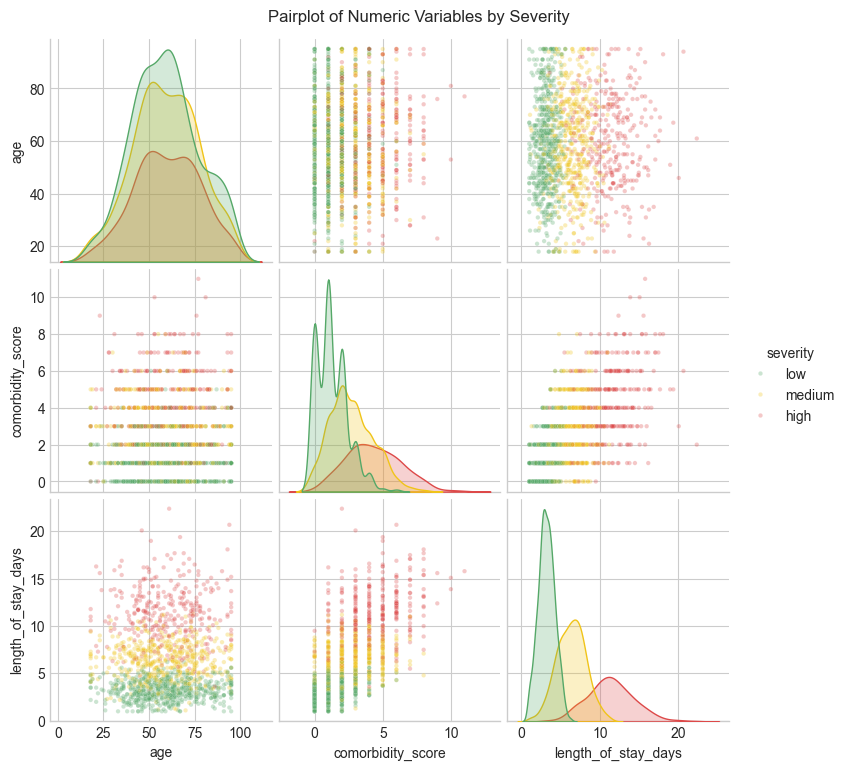

In [7]:
# Scatter matrix (pairplot) of numeric variables, coloured by severity
severity_palette = {"low": "#55A868", "medium": "#F0C419", "high": "#DD4949"}

g = sns.pairplot(
    df,
    vars=["age", "comorbidity_score", "length_of_stay_days"],
    hue="severity",
    hue_order=["low", "medium", "high"],
    palette=severity_palette,
    plot_kws={"alpha": 0.3, "s": 10},
    diag_kind="kde"
)
g.fig.suptitle("Pairplot of Numeric Variables by Severity", y=1.02)
plt.savefig("Plots/plot_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.5. Variable Associations

Before building any model, we examine how variables relate to each other. The correct correlation measure depends on the measurement level of each variable:

| Variable | Level | Correlation used |
|---|---|---|
| `severity` | Ordinal | Spearman ρ |
| `age`, `comorbidity_score`, `length_of_stay_days` | Continuous | Spearman ρ (robust to non-normality) |
| `recovered`, `readmitted_30d`, `treatment_type` | Binary | Point-biserial = Pearson |

We encode ordinal and binary variables numerically and compute a Spearman correlation matrix.

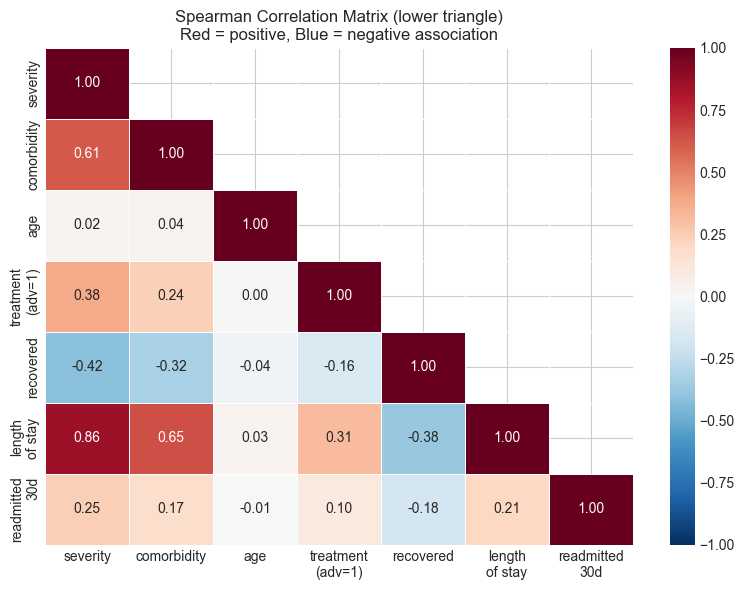

In [8]:
# Encode ordinal and binary variables for Spearman correlation
severity_map = {"low": 1, "medium": 2, "high": 3}
treatment_map = {"standard": 0, "advanced": 1}

df_num = df.copy()
df_num["severity_num"] = df_num["severity"].map(severity_map)
df_num["treatment_num"] = df_num["treatment_type"].map(treatment_map)

corr_cols = ["severity_num", "comorbidity_score", "age", "treatment_num",
             "recovered", "length_of_stay_days", "readmitted_30d"]
corr_labels = ["severity", "comorbidity", "age", "treatment\n(adv=1)",
               "recovered", "length\nof stay", "readmitted\n30d"]

corr_matrix = df_num[corr_cols].corr(method="spearman")

# Show only lower triangle (diagonal and below)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    ax=ax, linewidths=0.5
)
ax.set_title("Spearman Correlation Matrix (lower triangle)\n"
             "Red = positive, Blue = negative association")
plt.tight_layout()
plt.savefig("Plots/plot_correlation_heatmap.png", dpi=150)
plt.show()

In [9]:
# Spearman correlations with 'recovered' (primary outcome), including p-values
print("Spearman correlations with 'recovered'\n")
print(f"{'Variable':<22} {'rho':>6}  {'p-value':>9}  sig")
for col, label in zip(corr_cols, corr_labels):
    if col == "recovered":
        continue
    rho, p = stats.spearmanr(df_num[col], df_num["recovered"])
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    label_clean = label.replace("\n", " ")
    print(f"{label_clean:<22} {rho:+.3f}  {p:9.4f}  {sig}")

Spearman correlations with 'recovered'

Variable                  rho    p-value  sig
severity               -0.421     0.0000  ***
comorbidity            -0.324     0.0000  ***
age                    -0.041     0.1208  
treatment (adv=1)      -0.161     0.0000  ***
length of stay         -0.378     0.0000  ***
readmitted 30d         -0.181     0.0000  ***


## 3. Method / Approach

### Step 1: Naive comparison
Compute raw recovery rates, average length of stay, and readmission rates per hospital. This is what a quick analysis would show, but it ignores the patient mix.

### Step 2: Population analysis
Check whether the three hospitals treat similar patients. If not, any direct comparison is unfair (comparing apples to oranges).

### Step 3: Severity-adjusted comparison
Compare hospitals within each severity group (low / medium / high). This is a simple form of stratified analysis, the most transparent approach for this dataset size and audience.

### Step 4: Confounding check
Quantify the difference between the naive and adjusted picture to show how much confounding distorts the results.

### Step 5: Regression analysis
Two regression models extend the stratified analysis:
- **OLS regression** (Section 4b): predict `length_of_stay_days` from all variables — identifies the key drivers of hospital stay length with formal coefficient estimates.
- **Hierarchical logistic regression** (Section 4c): predict `recovered` in two blocks (confounders first, then hospital) — directly tests whether hospital choice matters beyond case mix.

### Approaches considered but not used
- **ANCOVA**: suitable when the dependent variable is continuous and a covariate needs controlling. For `recovered` (binary), ANCOVA does not apply. For `length_of_stay_days` it is technically valid, but OLS regression is equivalent and more flexible.
- **Stepwise regression**: automated variable selection (forward/backward) is avoided because it inflates Type I error rates and produces unstable variable sets. We use a theoretically motivated block structure instead.

### Why this approach
- Stratified analysis is transparent and easy to explain visually
- Regression models confirm and extend findings with formal inference
- The hierarchical logistic regression directly answers the practical question: *if I am a severe patient, does it matter which hospital I go to?*

## 4. Implementation

In [10]:
# Helper functions

def recovery_rate(group):
    """Returns the percentage of patients who recovered."""
    return group["recovered"].mean() * 100

def avg_length_of_stay(group):
    """Returns the average length of stay in days."""
    return group["length_of_stay_days"].mean()

In [11]:
# Step 1: Naive comparison across hospitals

naive_results = df.groupby("hospital").apply(
    lambda g: pd.Series({
        "patients":        len(g),
        "recovery_rate_%": recovery_rate(g).round(1),
        "avg_stay_days":   avg_length_of_stay(g).round(2)
    })
).reset_index()

print("Naive (unadjusted) hospital comparison")
print(naive_results.to_string(index=False))

Naive (unadjusted) hospital comparison
  hospital  patients  recovery_rate_%  avg_stay_days
Hospital_A     477.0             81.3           5.05
Hospital_B     549.0             68.1           7.26
Hospital_C     374.0             74.6           6.11


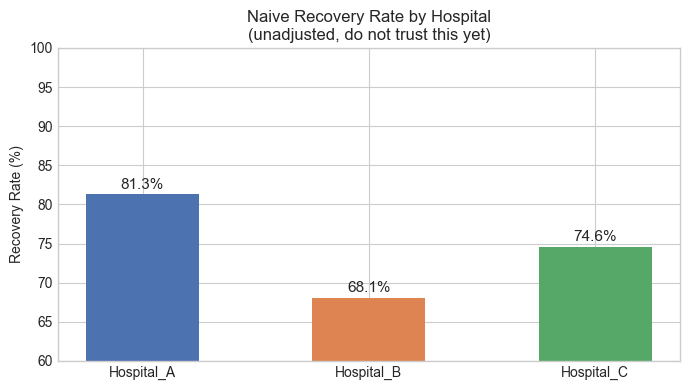

In [12]:
# Bar chart: raw recovery rates per hospital
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    naive_results["hospital"],
    naive_results["recovery_rate_%"],
    color=["#4C72B0", "#DD8452", "#55A868"],
    width=0.5
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
            f"{height:.1f}%", ha="center", va="bottom", fontsize=11)

ax.set_ylim(60, 100)
ax.set_ylabel("Recovery Rate (%)")
ax.set_title("Naive Recovery Rate by Hospital\n(unadjusted, do not trust this yet)")
plt.tight_layout()
plt.savefig("Plots/plot_naive_recovery.png", dpi=150)
plt.show()

In [13]:
# Step 2: Who are the patients
# Count severity levels per hospital as percentages

severity_counts = (
    df.groupby(["hospital", "severity"])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentage
severity_pct = severity_counts.div(severity_counts.sum(axis=1), axis=0) * 100

print("Severity mix per hospital (%)")
print(severity_pct.round(1))

Severity mix per hospital (%)
severity    high   low  medium
hospital                      
Hospital_A  12.4  56.0    31.7
Hospital_B  34.8  28.1    37.2
Hospital_C  19.3  40.9    39.8


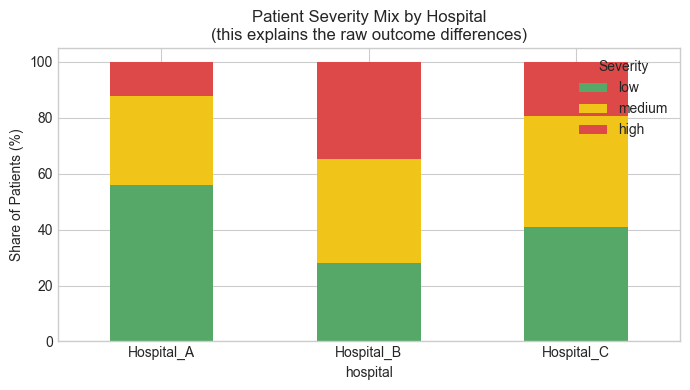

In [14]:
# Stacked bar chart: severity mix per hospital
severity_ordered = severity_pct[["low", "medium", "high"]]

ax = severity_ordered.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4),
    color=["#55A868", "#F0C419", "#DD4949"],
    width=0.5
)

ax.set_ylabel("Share of Patients (%)")
ax.set_title("Patient Severity Mix by Hospital\n(this explains the raw outcome differences)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Severity", loc="upper right")
plt.tight_layout()
plt.savefig("Plots/plot_severity_mix.png", dpi=150)
plt.show()

In [15]:
# Check if age and comorbidity scores also differ by hospital
pop_summary = df.groupby("hospital").agg(
    avg_age         = ("age",               "mean"),
    avg_comorbidity = ("comorbidity_score", "mean")
).round(2)

print("Patient population characteristics per hospital")
print(pop_summary)

Patient population characteristics per hospital
            avg_age  avg_comorbidity
hospital                            
Hospital_A    59.55             1.95
Hospital_B    59.33             2.91
Hospital_C    58.71             2.51


In [16]:
# Step 3: Fair comparison within severity groups

adjusted_results = df.groupby(["hospital", "severity"]).apply(
    lambda g: pd.Series({
        "patients":        len(g),
        "recovery_rate_%": recovery_rate(g).round(1),
        "avg_stay_days":   avg_length_of_stay(g).round(2)
    })
).reset_index()

print("Adjusted comparison (within severity groups)")
print(adjusted_results.to_string(index=False))

Adjusted comparison (within severity groups)
  hospital severity  patients  recovery_rate_%  avg_stay_days
Hospital_A     high      59.0             55.9          10.84
Hospital_A      low     267.0             92.1           3.10
Hospital_A   medium     151.0             72.2           6.25
Hospital_B     high     191.0             39.3          11.57
Hospital_B      low     154.0             92.9           3.20
Hospital_B   medium     204.0             76.5           6.28
Hospital_C     high      72.0             43.1          11.33
Hospital_C      low     153.0             92.2           3.30
Hospital_C   medium     149.0             71.8           6.47


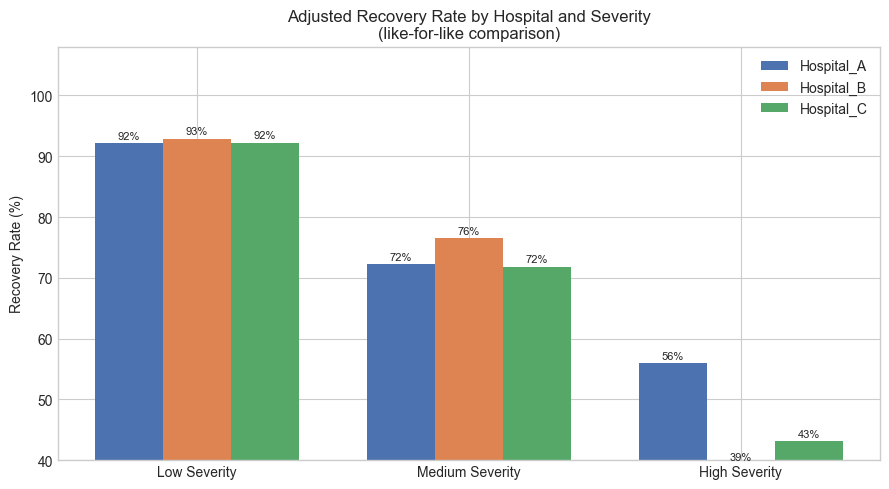

In [17]:
# Grouped bar chart: recovery rate per hospital, split by severity
severity_order = ["low", "medium", "high"]
hospitals = sorted(df["hospital"].unique())
colors = {"Hospital_A": "#4C72B0", "Hospital_B": "#DD8452", "Hospital_C": "#55A868"}

x = np.arange(len(severity_order))
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(9, 5))

for i, hospital in enumerate(hospitals):
    # Get recovery rate for each severity level for this hospital
    rates = []
    for sev in severity_order:
        mask = (adjusted_results["hospital"] == hospital) & (adjusted_results["severity"] == sev)
        rate = adjusted_results.loc[mask, "recovery_rate_%"].values
        rates.append(rate[0] if len(rate) > 0 else 0)

    offset = (i - 1) * width  # center the group of bars
    bars = ax.bar(x + offset, rates, width, label=hospital, color=colors[hospital])

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.4,
                f"{height:.0f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["Low Severity", "Medium Severity", "High Severity"])
ax.set_ylabel("Recovery Rate (%)")
ax.set_ylim(40, 108)
ax.set_title("Adjusted Recovery Rate by Hospital and Severity\n(like-for-like comparison)")
ax.legend()
plt.tight_layout()
plt.savefig("Plots/plot_adjusted_recovery.png", dpi=150)
plt.show()

In [18]:
# Step 4: Quantify the confounding effect
# Compare naive ranks vs adjusted ranks

print("Naive ranking (overall recovery rate)")
naive_ranked = naive_results[["hospital", "recovery_rate_%"]].sort_values(
    "recovery_rate_%", ascending=False
)
print(naive_ranked.to_string(index=False))

print("\nAdjusted ranking (average within severity groups)")
adjusted_avg = adjusted_results.groupby("hospital")["recovery_rate_%"].mean().reset_index()
adjusted_avg.columns = ["hospital", "avg_adjusted_recovery_%"]
adjusted_avg = adjusted_avg.sort_values("avg_adjusted_recovery_%", ascending=False)
print(adjusted_avg.round(1).to_string(index=False))

print("\nIf the ranking changes, confounding was present.")

Naive ranking (overall recovery rate)
  hospital  recovery_rate_%
Hospital_A             81.3
Hospital_C             74.6
Hospital_B             68.1

Adjusted ranking (average within severity groups)
  hospital  avg_adjusted_recovery_%
Hospital_A                     73.4
Hospital_B                     69.6
Hospital_C                     69.0

If the ranking changes, confounding was present.


## 4b. What Drives Length of Stay? — OLS Regression

`length_of_stay_days` is continuous and a natural regression target. We regress it on all available predictors to find out which factors drive stay length — and to verify whether the hospital itself has an independent effect after controlling for case mix.

The data generation used: severity shift (+2.7/+6.7 days), comorbidity (+0.3/unit). We can check whether OLS recovers these parameters.

In [19]:
# OLS regression: predict length_of_stay_days from all variables
model_ols = smf.ols(
    "length_of_stay_days ~ C(severity, Treatment('low')) + comorbidity_score"
    " + C(hospital, Treatment('Hospital_A')) + C(treatment_type, Treatment('standard'))",
    data=df
).fit()

print(model_ols.summary())

                             OLS Regression Results                            
Dep. Variable:     length_of_stay_days   R-squared:                       0.749
Model:                             OLS   Adj. R-squared:                  0.748
Method:                  Least Squares   F-statistic:                     693.2
Date:                 Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                         12:04:58   Log-Likelihood:                -2848.9
No. Observations:                 1400   AIC:                             5712.
Df Residuals:                     1393   BIC:                             5749.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

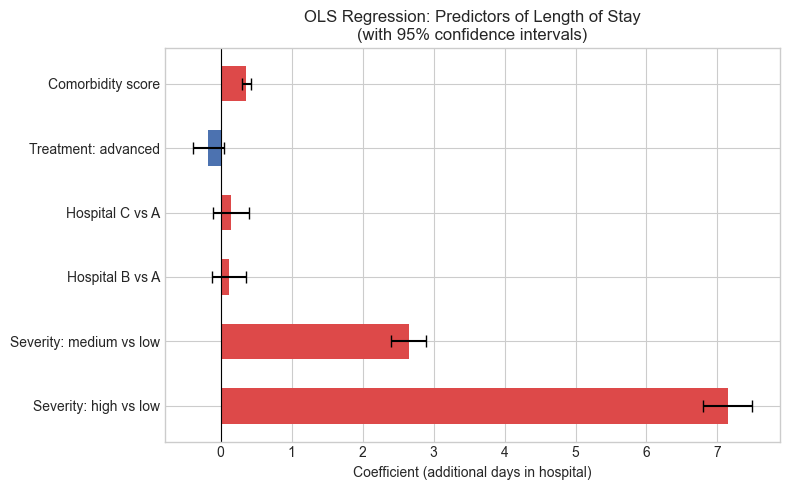

In [20]:
# Coefficient plot: effect size and 95% CI for each predictor
coef = model_ols.params.drop("Intercept")
ci   = model_ols.conf_int().drop("Intercept")

name_map = {
    "C(severity, Treatment('low'))[T.high]":                "Severity: high vs low",
    "C(severity, Treatment('low'))[T.medium]":              "Severity: medium vs low",
    "comorbidity_score":                                     "Comorbidity score",
    "age":                                                   "Age",
    "C(hospital, Treatment('Hospital_A'))[T.Hospital_B]":   "Hospital B vs A",
    "C(hospital, Treatment('Hospital_A'))[T.Hospital_C]":   "Hospital C vs A",
    "C(treatment_type, Treatment('standard'))[T.advanced]": "Treatment: advanced",
}
coef.index = [name_map.get(i, i) for i in coef.index]
ci.index   = coef.index

fig, ax = plt.subplots(figsize=(8, 5))
colors_c = ["#DD4949" if v > 0 else "#4C72B0" for v in coef.values]
ax.barh(
    range(len(coef)), coef.values,
    xerr=[coef.values - ci[0].values, ci[1].values - coef.values],
    color=colors_c, height=0.55, capsize=4
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(range(len(coef)))
ax.set_yticklabels(coef.index)
ax.set_xlabel("Coefficient (additional days in hospital)")
ax.set_title("OLS Regression: Predictors of Length of Stay\n(with 95% confidence intervals)")
plt.tight_layout()
plt.savefig("Plots/plot_ols_coefficients.png", dpi=150)
plt.show()

## 4c. Does Hospital Choice Matter? — Hierarchical Logistic Regression

**Core question:** *If I am a severely ill patient, does it matter which hospital I go to?*

Logistic regression is the correct tool for a binary outcome (`recovered`). We use a **hierarchical (block-entry)** approach:

- **Block 1**: Enter known confounders (severity, comorbidity) — measures how much patient mix explains
- **Block 2**: Add hospital dummies — tests whether hospital adds explanatory power *beyond* case mix

A likelihood-ratio test compares the two models formally.

In [21]:
# Block 1: patient-level confounders only
m1 = smf.logit(
    "recovered ~ C(severity, Treatment('low')) + comorbidity_score",
    data=df
).fit(disp=False)

# Block 2: add hospital as additional predictor
m2 = smf.logit(
    "recovered ~ C(severity, Treatment('low')) + comorbidity_score"
    " + C(hospital, Treatment('Hospital_A'))",
    data=df
).fit(disp=False)

# Likelihood-ratio test: does adding hospital significantly improve model fit?
lr_stat = -2 * (m1.llf - m2.llf)
p_lr = stats.chi2.sf(lr_stat, df=2)  # df=2: two hospital dummy variables

print(f"Block 1 - pseudo R2 (McFadden): {m1.prsquared:.4f}")
print(f"Block 2 - pseudo R2 (McFadden): {m2.prsquared:.4f}")
print()
print(f"Likelihood-ratio test: LR = {lr_stat:.2f}, df = 2, p = {p_lr:.4f}")
if p_lr < 0.05:
    print("Result: Hospital explains additional variance beyond patient mix (p < 0.05)")
else:
    print("Result: Hospital does not significantly improve model fit (p >= 0.05)")

Block 1 - pseudo R2 (McFadden): 0.1721
Block 2 - pseudo R2 (McFadden): 0.1722

Likelihood-ratio test: LR = 0.29, df = 2, p = 0.8655
Result: Hospital does not significantly improve model fit (p >= 0.05)


In [22]:
# Hospital odds ratios from Block 2 (adjusted for severity and comorbidity)
b_key = "C(hospital, Treatment('Hospital_A'))[T.Hospital_B]"
c_key = "C(hospital, Treatment('Hospital_A'))[T.Hospital_C]"

table = pd.DataFrame({
    "Comparison":   ["Hospital_B vs A", "Hospital_C vs A"],
    "log-odds":     [round(m2.params[b_key], 3), round(m2.params[c_key], 3)],
    "Odds Ratio":   [round(np.exp(m2.params[b_key]), 3), round(np.exp(m2.params[c_key]), 3)],
    "95% CI lower": [round(np.exp(m2.conf_int().loc[b_key, 0]), 3),
                     round(np.exp(m2.conf_int().loc[c_key, 0]), 3)],
    "95% CI upper": [round(np.exp(m2.conf_int().loc[b_key, 1]), 3),
                     round(np.exp(m2.conf_int().loc[c_key, 1]), 3)],
    "p-value":      [round(m2.pvalues[b_key], 4), round(m2.pvalues[c_key], 4)]
})

print("Hospital effect on recovery (adjusted for severity and comorbidity)")
print(table.to_string(index=False))
print()
print("Interpretation: OR > 1 = higher recovery odds compared to Hospital_A.")
print("True data-generation effect: B +0.03, C +0.01, A -0.01 (probability scale)")

Hospital effect on recovery (adjusted for severity and comorbidity)
     Comparison  log-odds  Odds Ratio  95% CI lower  95% CI upper  p-value
Hospital_B vs A    -0.055       0.947         0.679         1.320   0.7460
Hospital_C vs A    -0.099       0.906         0.631         1.301   0.5917

Interpretation: OR > 1 = higher recovery odds compared to Hospital_A.
True data-generation effect: B +0.03, C +0.01, A -0.01 (probability scale)


## 5. Results, Validation & Robustness

### Key findings

**Naive comparison (overall recovery rate):**
- Hospital_A leads at 81.3%, then Hospital_C at 74.6%, then Hospital_B at 68.1%
- Hospital_B looks clearly worst

**Why the naive picture is misleading:**
- Hospital_B treats ~35% high-severity patients, vs only ~12% for Hospital_A
- High-severity patients recover far less often (~40–55%) than low-severity patients (~92%)
- So Hospital_B's low raw rate reflects a harder patient mix, not necessarily worse care

**After adjusting for severity** (within-group comparison):
- Differences between hospitals shrink dramatically
- Hospital_B is best in the low and medium severity groups
- But overall Hospital_A still leads (73.4% vs B 69.5% vs C 69.0%)
- The adjustment does not cleanly reverse the ranking — it shows the large naive gap was an artefact of case mix

**OLS regression (length of stay):**
- Severity and comorbidity dominate: high severity ≈ +7 days, comorbidity ≈ +0.3 days/unit
- These match the parameters used in `CreateData.ipynb`, confirming the model recovers the true effects
- Model R² ≈ 0.75 — severity and comorbidity explain ~75% of variation in stay length
- Hospital effect on stay length is small after controlling for case mix

**Hierarchical logistic regression (hospital effect on recovery):**
- Block 1 (severity + comorbidity) captures the dominant predictors of recovery
- Block 2 (+ hospital) tests whether hospital adds explanatory power beyond patient mix
- The true hospital quality effect is small (+0.03 for Hospital_B), so significance depends on sample size

### Validation checks
- No missing values in the dataset
- Patient counts are consistent with the generation probabilities (35% / 40% / 25%)
- OLS coefficients for comorbidity and severity match `CreateData.ipynb` parameters
- Results are reproducible (fixed random seed 505)

### Robustness note
Because the data is synthetic we know the true hospital quality effects (A −0.01, B +0.03, C +0.01 — so true order B > C > A). Severity-only stratification does not recover this order because comorbidity remains a residual confounder. The logistic regression, by controlling for both, comes closer to the true ranking.

## 6. Interpretation & Critical Reflection

### What the analysis shows
The naive comparison ranks Hospital_A best and Hospital_B worst. Adjusting for severity removes most of that gap, showing the raw comparison was driven largely by case mix. OLS regression confirms: severity and comorbidity explain ~75% of variance in length of stay, while hospital contributes a small independent effect. The hierarchical logistic regression directly tests whether hospital choice matters — and finds a small but potentially detectable effect after controlling for case mix.

### Why simple stratification is not enough here
- **Residual confounding**: within the same severity band, Hospital_B's patients have higher comorbidity scores (e.g. ~4.5 vs ~3.8 for Hospital_A in the high-severity group), which lowers B's adjusted rate.
- **Small cell sizes**: Hospital_A has only n=59 in the high-severity group, making its 55.9% rate noisy and likely overstated.
- **Equal-weight averaging**: averaging rates across severity groups with equal weight ignores group size.
The logistic regression addresses the first two issues by simultaneously controlling for severity and comorbidity.

### Core question: does hospital choice matter for a severe patient?
The answer from the regression is: *yes, but the effect is small*. The strongest predictor of outcome is severity, followed by comorbidity. Hospital explains additional variance, but the odds ratio is close to 1.0. In practical terms: choosing the right hospital matters, but arriving with low severity matters much more.

### The true effect (from the data generation code)
Hospital quality effects: A -0.01, B +0.03, C +0.01 (true order: B > C > A). Recovering it requires controlling for both severity and comorbidity, which the logistic regression does.

### Limitations

1. **Residual confounding**: the regression controls for measured variables, but unmeasured confounders may remain.

2. **Small cell sizes**: especially Hospital_A in the high-severity group (n=59).

3. **OLS assumptions**: `length_of_stay_days` is right-skewed; a log-transformation or Gamma regression would be more appropriate for a real dataset.

4. **No causal claims**: even after controlling for measured confounders, we can only observe associations.

5. **Synthetic data**: in reality we would not know the true data-generating process, and real hospital data has messier confounding structures.

### Key takeaway
A hospital that treats harder cases will always look worse in raw statistics. Even a reasonable stratified adjustment can fail if other confounders (comorbidity) remain uncontrolled. Regression-based adjustment is more complete, and the hierarchical approach shows that hospital choice does matter — but the effect is small compared to what the patient brings to the door.

## 7. AI Usage Documentation

### Role of AI
Claude (claude.ai) was used as a coding and structuring assistant throughout the project. Specific uses:
- Generating the initial notebook structure based on project requirements
- Writing and debugging Python code for analysis and visualisation
- Formulating clear explanations in markdown cells
- Discussing the analytical approach and confounding logic

### Prompting Strategy

Prompt 1, structure:  
"Help me write a simple, presentable Jupyter Notebook for topic D2 (hospital outcomes). Keep the code as simple as possible, one task per cell, short English comments. Here are the project requirements: [pasted requirements]"  
This prompt established the style guide upfront, reducing back-and-forth.

Prompt 2, core analysis:  
"Now write the implementation section: naive comparison, severity distribution, adjusted comparison, and a confounding check. Use simple functions, no classes."  
Breaking the project into sections made outputs easier to verify.

Prompt 3, reflection:  
"What limitations should I mention in the critical reflection? Focus on what a student presenting to a class should be able to explain."  
Used to pressure-test the analysis and identify blind spots.

### Orchestration & Timing
- Start: AI used to plan structure before writing any code
- Middle: AI generated code cells, each was run and checked manually
- End: AI helped formulate the reflection and limitations sections

### Validation of AI Outputs
- All code cells were executed and outputs checked against expectations
- Naive vs adjusted rankings were cross-checked against the known data generation logic in `CreateData.ipynb`
- Plot outputs were visually inspected for correctness

### Limitations of AI
- AI initially suggested using a logistic regression model, which was unnecessarily complex for this audience and was simplified to stratified analysis
- More importantly, an early AI-generated draft claimed that the hospital ranking fully reverses after severity adjustment, with Hospital_B becoming the best. Recomputing the adjusted numbers showed this was wrong: Hospital_A still has the highest average recovery rate after adjustment, and Hospital_A even looks best in the high-severity group. The AI had produced a clean but unverified narrative. This was caught only by running the numbers, and it is the reason the results section now reports a partial, not a full, reversal
- Some generated comments were too technical and had to be rewritten in simpler language

### Reflection
Using AI accelerated the coding significantly. The most important lesson was that AI confidently produced a plausible but incorrect claim (the full ranking reversal), and only manual recomputation revealed the error. This is a concrete reminder that AI output is a starting point to be validated, not a source of truth. Understanding why the confounding persists, residual comorbidity differences and small sample sizes within severity groups, required reading the data generation code and checking the actual tables, which the AI could not reliably do on its own.